In [1]:
from pathlib import Path
import matplotlib.pyplot as plt

from gsm_benchmarker.results_analyser import MultiVariantMultiModelResultsAnalyser
from gsm_benchmarker.results_analyser.prompt_effect_analyser import PromptEffectAnalyser

plt.style.use('seaborn-v0_8-muted')
plt.style.use('seaborn-v0_8-darkgrid')

In [2]:
pp = Path("../../../../data/gsm-symbolic/outputs").resolve()
p_standard = pp / "mini_20x50x4__14_11/final"
# p_sep = pp / 'separated_targets_20x50x4__26_11/final'
p_sep = pp / 'mini_sep_new__20x50__20_12/final'
p_code = pp / 'mini_code_output_20x50__05_12/final'

In [3]:
mres_standard = MultiVariantMultiModelResultsAnalyser(p_standard)
mres_sep = MultiVariantMultiModelResultsAnalyser(p_sep)
mres_code = MultiVariantMultiModelResultsAnalyser(p_code)

Model: 100%|██████████| 5/5 [00:01<00:00,  3.28it/s]


In [4]:
pea_sep = PromptEffectAnalyser(mres_standard, mres_sep, "Anti-babbling prompt")

In [5]:
res = pea_sep.compare_core_stats(variant='main', detailed_output=True)
# res.xs('correct_strict', level='param')
res

mean_diff   p_value  \
model                                param                                
google_gemma-2-27b-it                correct           -0.007  0.413356   
                                     correct_strict     0.644       0.0   
                                     babbling          -0.701       0.0   
google_gemma-2-2b                    correct            0.002  0.715682   
                                     correct_strict     0.004  0.042086   
                                     babbling          -0.118       0.0   
google_gemma-2-2b-it                 correct            0.051  0.000197   
                                     correct_strict     0.356       0.0   
                                     babbling           -0.71       0.0   
google_gemma-2-9b                    correct           -0.022  0.143818   
                                     correct_strict     0.586       0.0   
                                     babbling          -0.981       0.0   
google_gemma-2-9b-it                 correct           -0.723       0.0   
                                     correct_strict    -0.723       0.0   
                                     babbling             0.0       NaN   
google_gemma-2b                      correct              0.0       1.0   
                                     correct_strict       0.0       NaN   
                                     babbling          -0.036  0.004036   
google_gemma-2b-it                   correct           -0.014  0.018762   
                                     correct_strict    -0.014  0.018762   
                                     babbling             0.0       NaN   
google_gemma-7b                      correct           -0.064  0.000011   
                                     correct_strict     0.101       0.0   
                                     babbling          -0.623       0.0   
google_gemma-7b-it                   correct           -0.105   0.00003   
                                     correct_strict    -0.128  0.000001   
                                     babbling           0.152       0.0   
meta-llama_Meta-Llama-3-8B           correct           -0.084  0.000002   
                                     correct_strict     0.235       0.0   
                                     babbling          -0.558       0.0   
meta-llama_Meta-Llama-3-8B-Instruct  correct            0.007   0.48681   
                                     correct_strict     0.138       0.0   
                                     babbling          -0.241       0.0   
microsoft_Phi-3-medium-128k-instruct correct           -0.021  0.030771   
                                     correct_strict     0.112       0.0   
                                     babbling          -0.159       0.0   
microsoft_Phi-3-mini-128k-instruct   correct           -0.021  0.150825   
                                     correct_strict     0.715       0.0   
                                     babbling           -0.98       0.0   
microsoft_Phi-3_5-mini-instruct      correct           -0.026  0.065584   
                                     correct_strict     0.714       0.0   
                                     babbling          -0.982       0.0   
microsoft_phi-2                      correct           -0.148       0.0   
                                     correct_strict     0.083       0.0   
                                     babbling          -0.389       0.0   
mistralai_Mathstral-7B-v0_1          correct           -0.045  0.000873   
                                     correct_strict     0.091       0.0   
                                     babbling          -0.165       0.0   
mistralai_Mistral-7B-Instruct-v0_1   correct            0.032  0.043894   
                                     correct_strict     0.062  0.001187   
                                     babbling           -0.12       0.0   
mistralai_Mistral-7B-Instruct-v0_3   correct            -0.02   0.14443   
  

In [6]:
pea_sep.compare_core_stats(variant='main')

,significant,success,failure
param,,,
babbling,18,17,1
correct,12,2,10
correct_strict,18,15,3


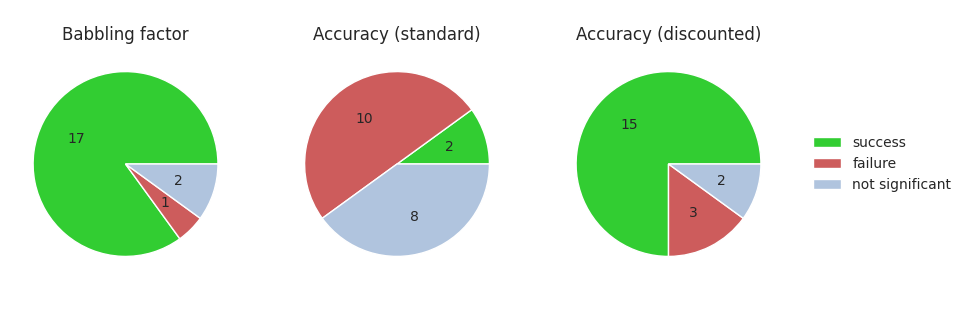

In [7]:
fig, cs = pea_sep.plot_core_stats('main')

